# Exploratory Data Analysis

The goal of this notebook is to explore the datasets of this thesis. The datasets are in four different languages, English, French, Korean and Japanese. Each language has a train and a test set. We will explore and analyze each dataset by the language that it is written. It is an important step in order to take all the information which is needed to do this thesis and make right decisions by taking the advantage of all the information of our datsets provide. 

### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import eda_functions

### ENGLISH DATASET

Let's begin with the English dataset, which will be our base of this thesis.
It is important to look every detail, and take the opportunity to gain as much information as we can. 

####  Convert JSON files to dataframes
The english dataset is a JSON file. This means that has a form which looks like this : <br> 

    {
        "URL": "https://www.esgtoday.com/arabesque-ai-appoints-carolina-minio-paluello-as-new-ceo/",
        "news_title": "Arabesque AI Appoints Carolina Minio Paluello as New CEO",
        "news_content": "ESG-focused financial technology company Arabesque AI announced today the appointment of Dr. Carolina Minio Paluello as the company\u2019s new Chief Executive Officer.",
        "impact_level": "low",
        "impact_length": "2 to 5 years"
    }

Above, we can see a part of the dataset. Specifically we can see the first "element" of the dataset. Now, we want to convert the JSON file to a dataframe in order to explore it. 

In [2]:
train_en = pd.read_json('datasets/competition/ML-ESG-3_Trainset_English.json')
test_en = pd.read_json('datasets/competition/ML-ESG3_Testset_EN.json')

#### Exploration of the English Dataset
Firstly, let's have a look of our english dataframe.

In [3]:
train_en.head()

,URL,news_title,news_content,impact_level,impact_length
0,https://www.esgtoday.com/arabesque-ai-appoints...,Arabesque AI Appoints Carolina Minio Paluello ...,ESG-focused financial technology company Arabe...,low,2 to 5 years
1,https://www.esgtoday.com/arabesque-ai-appoints...,Arabesque AI Appoints Carolina Minio Paluello ...,The company also announced the appointment of ...,low,2 to 5 years
2,https://www.esgtoday.com/arabesque-ai-appoints...,Arabesque AI Appoints Carolina Minio Paluello ...,Wong said: \n“Personalised portfolios demand ...,medium,2 to 5 years
3,https://www.esgtoday.com/ukraine-war-inflation...,"Ukraine War, Inflation Reduction Act Driving F...",One of the key themes of the report is the imp...,high,More than 5 years
4,https://www.esgtoday.com/eu-regulators-welcome...,"EU Regulators Welcome, Critique New European S...",Europe’s three primary financial regulatory ag...,medium,Less than 2 years


We can observe that the dataframe has five unique attributes. The "URL", the "news_title", the "news_content", the "impact_level", and the "impact_length". It is more or less understandable what each attribute means but let's explain each one, one by one. 
- **"URL"** : This attribute has the url of the article which we gain all the information about. Of course, each url is real, so our data has real-world senarios of ESG issues. 
- **"news_title"** : Keep in mind that the data was triggered by real articles. We all know that every article has a title. This attribute represents the title of the article.
- **"news_content"** : The main text of the article it is saved in this attribute. 
- **"impact_level"** : It shows us the impact level of ESG issues of the specific article.
- **"impact_length"** : It shows us the duration that causes this specific ESG issue of this article. <br> 

Now, let's have a look the shape of our English datasets. 

In [4]:
print(f"Shape of the trainset: {train_en.shape}")
print(f"Shape of the testset: {test_en.shape}")

Shape of the trainset: (545, 5)
Shape of the testset: (136, 5)


Let's concentrate at the **train dataset**. <br> 
It important always to look the missing values and the type of each column. 

In [5]:
display(train_en.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   URL            545 non-null    object
 1   news_title     545 non-null    object
 2   news_content   545 non-null    object
 3   impact_level   545 non-null    object
 4   impact_length  545 non-null    object
dtypes: object(5)
memory usage: 21.4+ KB


None

As we can observe each attribute has no missing values. The types are objects which is totally normal as every attribute has a text value. ( You can look above the part of the dataset. ) To continue, how many unique values has each attribute? 

In [6]:
print(train_en.nunique())

URL              339
news_title       339
news_content     545
impact_level       3
impact_length      3
dtype: int64


Remember, our trainset has 545 rows - elements. With the above results we can make the below observations : 
- There are articles which was used more than once but with different news_content, which means that different part of a specific article was taken. This happens because "URL" and "news_title" have 339 unique attributes.
- "impact_level" and "impact_length" are categorical features as they have only three unique values. <br> 

Let's make more observation for each attribute. 
#### **URL** 
By having the first look to the train dataset we can see that most of the URLs looks like that there are from "esgtoday". How many of them are from this website? 

In [7]:
count_esgtoday = train_en[train_en['URL'].str.startswith('https://www.esgtoday.com')].shape[0]
print(count_esgtoday)

523


More than 95% of the english dataset are from the same website - "ESG Today". (523 out of 545)

#### **News_content**
News_content is the most valuable feature because it contains all the information an article provides about the ESG issue we are analyzing. From this single attribute, we can make predictions and extract valuable insights. Let’s take a closer look at the type of text it contains.

In [8]:
news_content_lengths = train_en['news_content'].apply(len)

min_length = news_content_lengths.min()
max_length = news_content_lengths.max()

print(min_length)
print(max_length)

59
1147


The values above indicate the minimum and maximum character lengths of the news_content attribute. As shown, the texts are relatively short, usually consisting of a single sentence or a brief paragraph.
#### **Impact Level** and **Impact Length**
We have already explained that the **impact_level** is a categorical attribute with three classes: :

In [9]:
print("Below are the categorical values of impact_level")
train_en['impact_level'].unique()

Below are the categorical values of impact_level


array(['low', 'medium', 'high'], dtype=object)

We have already explained that the impact level is a categorical attribute with three classes:

- Low: issues with minimal impact on ESG factors,
- Medium: issues that have a measurable impact on ESG factors,
- High: issues that exert a significant impact on ESG factors.

It is important to note that these categories do not indicate whether the impact is positive or negative, but rather the extent of the impact itself.
For the same reasons, we will apply the same approach to the **impact_length** attribute.

In [10]:
print("Below are the categorical values of impact_length")
train_en['impact_length'].unique()

Below are the categorical values of impact_length


array(['2 to 5 years', 'More than 5 years', 'Less than 2 years'],
      dtype=object)

The impact length attribute has three unique values:

- Less than 2 years: issues whose impact lasts fewer than two years,
- 2 to 5 years: issues whose impact persists between two and five years,
- More than 5 years: issues whose impact extends beyond five years.

Once again, it is important to emphasize that these categories do not indicate whether the impact is positive or negative, but only its duration

##### Distribution of impact_level

In [11]:
fig = eda_functions.histogram(train_en, 'impact_level')

Our dataset for impact level classification demonstrates a moderate imbalance. The distribution of classes is as follows: low (106), medium (243), and high (196), which translates to approximately 25%, 57%, and 18% of the total samples, respectively.

In this context, the "low" class is the minority class, which may present challenges during model training, particularly if the model tends to favor the majority class. Conversely, the "medium" class serves as the majority, offering the model a substantial amount of data to learn from. This imbalance highlights the need for careful consideration in our modeling approach to ensure effective classification across all classes.

##### Distribution of impact_length

In [12]:
fig = eda_functions.histogram(train_en, 'impact_length')

Our dataset for impact length classification exhibits a moderate imbalance. The distribution of classes is as follows: less than 2 years (82), 2 to 5 years (198), and more than 5 years (265), which corresponds to approximately 19%, 46%, and 35% of the total samples, respectively.

In this case, the "less than 2 years" class is the minority, which may pose challenges during model training, especially if the model tends to favor the majority classes. Meanwhile, the "more than 5 years" class represents the majority, providing the model with a robust amount of data to learn from. This imbalance underscores the importance of adopting careful strategies in our modeling approach to ensure effective classification across all classes.



##### Confusion Matrix between those features

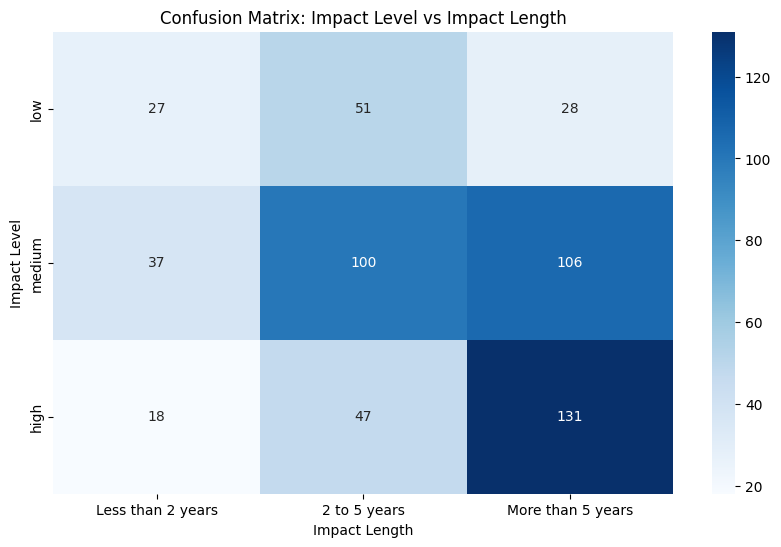

Impact Length  Less than 2 years  2 to 5 years  More than 5 years
Impact Level                                                     
low                           27            51                 28
medium                        37           100                106
high                          18            47                131


In [13]:
import importlib
importlib.reload(eda_functions)
cm = eda_functions.confusion_matrix(train_en)
print(cm)

From the above confusion matrix we can observe many things. Firstly, we can see that most cases are associated with "More than 5 years" as we have 131+106+28=265 cases. The data shows that high-impact projects are usually longer, especially those lasting "More than 5 years", indicating that longer projects often have a greater impact. Medium-impact projects are spread fairly evenly across different durations, suggesting that time doesn't heavily influence their impact level. On the other hand, low-impact projects tend to be shorter, with most lasting "2 to 5 years" or "less than 2 years", and fewer extending "More than 5 years".

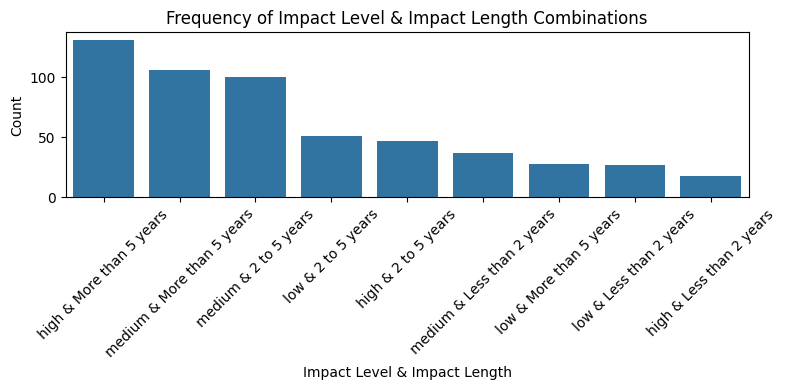

In [14]:
train_en['combination'] = train_en['impact_level'].astype(str) + ' & ' + train_en['impact_length'].astype(str)

plt.figure(figsize=(8, 4))
sns.countplot(x='combination', data=train_en, order=train_en['combination'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Frequency of Impact Level & Impact Length Combinations')
plt.xlabel('Impact Level & Impact Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### Encoding Categorical Features
In this step, the categorical features are encoded to improve the effectiveness of the dataset. The categories of impact level: low, medium, and high are represented by the numerical values 0, 1, and 2, respectively. Similarly, the categories of impact length: less than 2 years, 2 to 5 years, and more than 5 years are mapped to the values 0, 1, and 2.

In [15]:
train_en["impact_level"] = train_en["impact_level"].replace(["low","medium","high"],[0,1,2])
train_en["impact_length"] = train_en["impact_length"].replace(["Less than 2 years","2 to 5 years","More than 5 years"],[0,1,2])
test_en["impact_level"] = test_en["impact_level"].replace(["low","medium","high"],[0,1,2])
test_en["impact_length"] = test_en["impact_length"].replace(["Less than 2 years","2 to 5 years","More than 5 years"],[0,1,2])

train_en

,URL,news_title,news_content,impact_level,impact_length,combination
0,https://www.esgtoday.com/arabesque-ai-appoints...,Arabesque AI Appoints Carolina Minio Paluello ...,ESG-focused financial technology company Arabe...,0,1,low & 2 to 5 years
1,https://www.esgtoday.com/arabesque-ai-appoints...,Arabesque AI Appoints Carolina Minio Paluello ...,The company also announced the appointment of ...,0,1,low & 2 to 5 years
2,https://www.esgtoday.com/arabesque-ai-appoints...,Arabesque AI Appoints Carolina Minio Paluello ...,Wong said: \n“Personalised portfolios demand ...,1,1,medium & 2 to 5 years
3,https://www.esgtoday.com/ukraine-war-inflation...,"Ukraine War, Inflation Reduction Act Driving F...",One of the key themes of the report is the imp...,2,2,high & More than 5 years
4,https://www.esgtoday.com/eu-regulators-welcome...,"EU Regulators Welcome, Critique New European S...",Europe’s three primary financial regulatory ag...,1,0,medium & Less than 2 years
...,...,...,...,...,...,...
540,https://www.esgtoday.com/methane-emissions-det...,Methane Emissions Detection Platform Kuva Rais...,"Stefan Bokaemper, CEO of Kuva Systems, said: “...",0,1,low & 2 to 5 years
541,https://www.esgtoday.com/eaton-appoints-harold...,Eaton Appoints Harold Jones as Chief Sustainab...,Eaton Appoints Harold Jones as Chief Sustainab...,0,1,low & 2 to 5 years
542,https://www.esgtoday.com/ssga-outlines-2021-st...,"SSGA Outlines 2021 Stewardship Priorities, Wil...","In his letter, Taraporevala wrote: “As a signa...",1,0,medium & Less than 2 years
543,https://www.esgtoday.com/survey-investors-shif...,Survey: Investors Shifting to Offense on Clima...,O’Brien said: “Investors globally are increasi...,0,0,low & Less than 2 years


In [16]:
train_en.to_csv("datasets/update_datasets/train_df.csv", index=False)
test_en.to_csv("datasets/update_datasets/test_df.csv", index=False)

*Although the thesis focuses on an English dataset, it is also important to explore datasets in other languages. Such exploration often provides valuable insights and helps us better understand the overall structure of the data. In addition, analyzing datasets in different languages can reveal variations in attributes, vocabulary, and context that may not appear in the English texts. The notebook will also continue to explore the remaining datasets, with particular attention to the differences observed either in comparison to the English dataset or among the datasets themselves.*

## FRENCH DATASET
Here, we will focus on the french dataset. 

### Convert JSON files to dataframes

In [17]:
train_fr = pd.read_json('datasets/competition/ML-ESG-3_Trainset_French.json')
test_fr = pd.read_json('datasets/competition/ML-ESG3_Testset_FR.json')

### Exploration of the French Dataset

In [18]:
train_fr.head()

,URL,news_title,news_content,impact_level,impact_length
0,https://www.novethic.fr/actualite/energie/tran...,Interdiction à la location des passoires therm...,"Depuis le 1er janvier, les passoires thermique...",low,More than 5 years
1,https://www.novethic.fr/actualite/energie/tran...,Interdiction à la location des passoires therm...,"Depuis le 1er janvier 2023, les logements les ...",low,More than 5 years
2,https://www.novethic.fr/actualite/energie/tran...,Interdiction à la location des passoires therm...,Des exceptions pour les logements pas isolable...,low,More than 5 years
3,https://www.novethic.fr/actualite/energie/tran...,Interdiction à la location des passoires therm...,Des rapports qui se suivent et se ressemblent....,low,More than 5 years
4,https://www.novethic.fr/actualite/energie/tran...,Interdiction à la location des passoires therm...,"""Aujourd’hui, nous devons bouger, l’échéancier...",low,More than 5 years


In [19]:
display(train_fr.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 661 entries, 0 to 660
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   URL            661 non-null    object
 1   news_title     661 non-null    object
 2   news_content   661 non-null    object
 3   impact_level   661 non-null    object
 4   impact_length  661 non-null    object
dtypes: object(5)
memory usage: 25.9+ KB


None

It appears that the structure of the dataset is similar to the English one, with no new attributes and no missing values.

In [20]:
print(f"Shape of the trainset: {train_fr.shape}")
print(f"Shape of the testset: {test_fr.shape}")

Shape of the trainset: (661, 5)
Shape of the testset: (146, 5)


In the French-language dataset, the training set is larger than that of the English dataset.

In [21]:
print(train_fr.nunique())

URL              126
news_title       126
news_content     637
impact_level       3
impact_length      3
dtype: int64


The numbers above reveal that, although the training set is larger, much of the news_content comes from the same articles.

In [22]:
fig = eda_functions.histogram(train_fr, 'impact_level')

In [23]:
fig = eda_functions.histogram(train_fr, 'impact_length')

## JAPANESE DATASET
The Japanese language dataset is quite different from the ones discussed above. It is important to note that Japanese is unique compared to the other languages in our datasets because it uses three alphabets, with the most distinctive being Kanji. In the Kanji alphabet, each character represents a word or a combination of words. This is worth mentioning because, although the texts may have a specific length, their actual meaning can be much greater than expected.

### Convert JSON files to Dataframe

In [24]:
train_jpn = pd.read_json('datasets/competition/ML-ESG-3_Trainset_Japanese.json')
test_jpn = pd.read_json('datasets/competition/ML-ESG3_Testset_Japanese.json')

### Exploration of the Japanese dataset

In [25]:
train_jpn.head()

,ID,Text,Relevancy,ESG_type,Impact_type,Impact_duration
0,2376726,「環境レポーティング」、「事業における環境効率」など環境分野に関する取り組みについて高い評価...,Relevant,Environmental,Opportunity,within_2_years
1,62954128,その後、取締役会で「不二製油グループ本社コーポレートガバナンス・ガイドライン」を決議し同年1...,Relevant,Governance,Opportunity,within_2_years
2,19089671,早速ですが、ANAホールディングスさまがこの度日本企業として初の「人権報告書」を作成しました。,Relevant,Human_Capital,Opportunity,within_2_years
3,19089675,この一連の取り組みを今回「人権報告書」としてまとめ上げ、非財務情報開示の第一歩として踏み切り...,Relevant,Human_Capital,Opportunity,within_2_years
4,307552118,女性活躍推進に優れた上場企業「なでしこ銘柄」に住宅・建設業界で唯一4回選定されていることも、...,Relevant,Human_Capital,Opportunity,between_2_and_5_years


By examining the DataFrame, we can observe several differences compared to the previous ones. Firstly, it contains six distinct attributes:

- "ID": A unique identifier assigned to each entry.
- "Text": This is the same as the news_content attribute.
- "Relevancy": Indicates how relevant the news article is to ESG issues.
- "ESG_type": Specifies the particular ESG topic discussed. News articles don’t just refer to ESG in general but often focus on a specific aspect of it.
- "impact_type": This shows whether the issue has a positive potential or a negative potential.
- "impact_duration": Same as previously explained for the other languages.

It is important to note that, except for the "Text" column, which is in Japanese, all other attribute values are in English.

In [26]:
print(f"Shape of the trainset: {train_jpn.shape}")
print(f"Shape of the testset: {test_jpn.shape}")

Shape of the trainset: (53, 6)
Shape of the testset: (1500, 6)


Although it is an interesting dataset, the training set is too small for the models to be properly trained and evaluated.

In [27]:
print(train_jpn.nunique())

ID                 53
Text               53
Relevancy           2
ESG_type            6
Impact_type         3
Impact_duration     4
dtype: int64


In [28]:
print(test_jpn.nunique())

ID                 1500
Text               1481
Relevancy             3
ESG_type              6
Impact_type           3
Impact_duration       4
dtype: int64


All the attributes will be explained below. 
#### **ID** 
It is a unique code for each element. It contains a sequence of numbers, a big integer.

#### **Text**

In [29]:
text_lengths = train_jpn['Text'].apply(len)

min_length = text_lengths.min()
max_length = text_lengths.max()

print(min_length)
print(max_length)

37
100


As we can see, the character length appears short, but it contains a lot of information. Most entries consist of full paragraphs.

#### **Relevancy**

In [30]:
train_jpn['Relevancy'].unique()

array(['Relevant', 'Irrelevant'], dtype=object)

#### **ESG type**

In [31]:
train_jpn['ESG_type'].unique()

array(['Environmental', 'Governance', 'Human_Capital', '', 'ESG_general',
       'Social_Capital'], dtype=object)

In [32]:
counts = train_jpn['ESG_type'].value_counts().reset_index()
counts.columns = ['ESG_type', 'count']

# Create pie chart
fig = px.pie( counts, names='ESG_type', values='count', title='Distribution of ESG_type',color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

#### **Impact Type**

In [33]:
train_jpn['Impact_type'].unique()

array(['Opportunity', 'Risk', ''], dtype=object)

In [34]:
counts = train_jpn['Impact_type'].value_counts().reset_index()
counts.columns = ['Impact_type', 'count']

# Create bar chart
fig = px.bar(counts, x='Impact_type', y='count', color='Impact_type', title='Count of ESG Types', text='count', color_discrete_sequence=px.colors.qualitative.Pastel )
fig.show()

#### **Impact Duration**

In [35]:
train_jpn['Impact_duration'].unique()

array(['within_2_years', 'between_2_and_5_years', '',
       'longer_than_5_years'], dtype=object)

### Korean Dataset

The Korean-language dataset also differs from the previously discussed datasets. Korean uses the Hangul alphabet, which is unique compared to English and other Latin-based languages. Each Hangul character represents a syllable, which is made up of one or more letters, and these syllables combine to form words. This is noteworthy because, although the texts may appear short in terms of character count, their semantic content can be richer than expected.

In [36]:
train_kr = pd.read_json('datasets/competition/ML-ESG-3_Trainset_Korean.json')
test_kr = pd.read_json('datasets/competition/ML-ESG3_Testset_Korean.json')

In [37]:
train_kr.head()

,Unnamed: 0.1,Unnamed: 0,url,category,title,content,impact_type,impact_duration
0,0,0,https://www.esgeconomy.com/news/articleView.ht...,지속가능경제,액화수소 시대 열린다...연 4만톤 설비 연내 가동,"연내에 두산애너빌리티와 SK E&S, 효성중공업의 액화수소 플랜트가 준공돼 연간 최...",opportunity,2 to 5 years
1,1,1,https://www.esgeconomy.com/news/articleView.ht...,기업·거버넌스,"SK텔레콤, 자사주 소각 통해 지배구조 개편 한걸음",올해 하반기까지 사업재편을 완성하겠다는 SK텔레콤이 주주가치 제고를 위한 자사주 소...,opportunity,less than 2 years
2,2,2,https://www.esgeconomy.com/news/articleView.ht...,기업·거버넌스,500대 기업 중 공급망 ESG 관리 들어간 곳 27%뿐,유럽연합(EU)의 공급망실사법 도입과 공급망 온실가스 배출량 공시의무화 움직임 등을...,risk,less than 2 years
3,3,3,https://www.esgeconomy.com/news/articleView.ht...,환경·사회,국제 탄소배출권 가격 연일 사상최고치...유럽시장 70유로선 돌파,유럽연합(EU) 시장을 필두로 국제 탄소배출권 가격이 연일 사상최고치 행진을 이어가...,risk,less than 2 years
4,4,4,https://www.esgeconomy.com/news/articleView.ht...,환경·사회,美 서부의 생명수 '콜로라도강'을 지켜라,그랜드캐니언을 관통하면서 미 서부의 생명수 역할을 하는 콜로라도강에 비상이 걸렸다....,risk,2 to 5 years


By examining the DataFrame, we can observe a combination of attributes to the previous ones. Firstly, it contains six distinct attributes:

- "Unnamed: 0.1": A unique identifier assigned to each entry.
- "Unnamed: 0": A unique identifier assigned to each entry.
- "url": Same as previously explained for the other languages.
- "category": Specifies the particular ESG topic discussed. News articles don’t just refer to ESG in general but often focus on a specific aspect of it.
- "title": Same as previously explained for the other languages.
- "content": Same as previously explained for the other languages.
- "impact_type": Same as previously explained for the other languages.
- "impact_duration": Same as previously explained for the other languages.

It is important to note that, except for the "Text" column, which is in Japanese, all other attribute values are in English.

In [38]:
print(f"Shape of the trainset: {train_kr.shape}")
print(f"Shape of the testset: {test_kr.shape}")

Shape of the trainset: (800, 8)
Shape of the testset: (200, 8)


In [39]:
print(train_kr.nunique())

Unnamed: 0.1       800
Unnamed: 0         800
url                768
category             6
title              768
content            769
impact_type          3
impact_duration      3
dtype: int64


In [40]:
print(test_kr.nunique())

Unnamed: 0.1       200
Unnamed: 0         200
url                199
category             6
title              199
content            199
impact_type          3
impact_duration      3
dtype: int64


In [41]:
train_kr['category'].unique()

array(['지속가능경제', '기업·거버넌스', '환경·사회', '공시·평가', 'ESG 라이프', '오피니언'],
      dtype=object)

- '지속가능경제' : Sustainable Economy
- '기업·거버넌스' : Corporate & Governance
- '환경·사회' : Environment & Society
- '공시·평가' : Disclosure & Evaluation
- 'ESG 라이프' : ESG Life
- '오피니언' : Opinion

In [42]:
train_kr['impact_type'].unique()

array(['opportunity', 'risk', 'cannot distinguish'], dtype=object)

In [43]:
train_kr['impact_duration'].unique()


array(['2 to 5 years', 'less than 2 years', 'more than 5 years'],
      dtype=object)

Having summarized all the information above, let’s organize it into a table for clarity. This will provide a concise overview of each attribute, its description, and key characteristics, making it easier to reference throughout the analysis.

![My Table](images/Language_table.png)